In [1]:
!pip install opencv-python

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as PhuongMai

img = cv.imread('hinh1.jpg')
img2 = cv.imread('hinh2.jpg')

if img is None:
    raise FileNotFoundError("Không tìm thấy file hinh1.jpg")

if img2 is None:
    raise FileNotFoundError("Không tìm thấy file hinh2.jpg")

Số khuôn mặt phát hiện được: 5


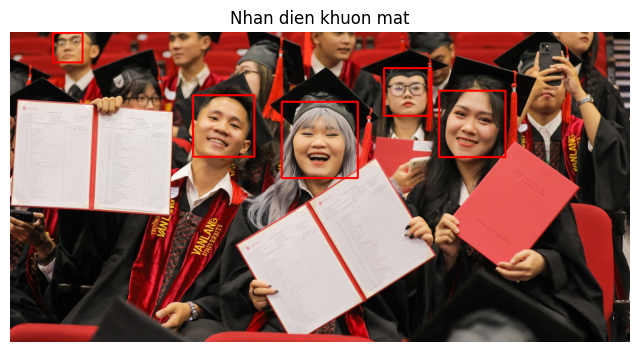

In [4]:
# =========================
# NHẬN DIỆN KHUÔN MẶT
# =========================

face_cascade = cv.CascadeClassifier('haarcascade_frontalface_default.xml')

if face_cascade.empty():
    raise FileNotFoundError("Không load được file haarcascade_frontalface_default.xml")

img_face = img.copy()
gray_face = cv.cvtColor(img_face, cv.COLOR_BGR2GRAY)
rgb_face = cv.cvtColor(img_face, cv.COLOR_BGR2RGB)

faces = face_cascade.detectMultiScale(
    gray_face,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    cv.rectangle(rgb_face, (x, y), (x + w, y + h), (255, 0, 0), 3)

print("Số khuôn mặt phát hiện được:", len(faces))

PhuongMai.figure(figsize=(8, 6))
PhuongMai.imshow(rgb_face)
PhuongMai.title("Nhan dien khuon mat")
PhuongMai.axis("off")
PhuongMai.show()

Số mắt phát hiện được: 12


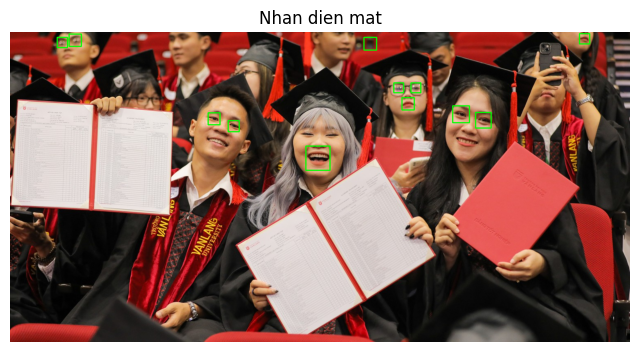

In [11]:
# =========================
# NHẬN DIỆN MẮT
# =========================

eye_cascade = cv.CascadeClassifier('haarcascade_eye.xml')

if eye_cascade.empty():
    raise FileNotFoundError("Không load được file haarcascade_eye.xml")

img_eye = img.copy()
gray_eye = cv.cvtColor(img_eye, cv.COLOR_BGR2GRAY)
rgb_eye = cv.cvtColor(img_eye, cv.COLOR_BGR2RGB)

eyes = eye_cascade.detectMultiScale(
    gray_eye,
    scaleFactor=1.1,
    minNeighbors=8,
    minSize=(20, 20)
)

for (x, y, w, h) in eyes:
    cv.rectangle(rgb_eye, (x, y), (x + w, y + h), (0, 255, 0), 2)

print("Số mắt phát hiện được:", len(eyes))

PhuongMai.figure(figsize=(8, 6))
PhuongMai.imshow(rgb_eye)
PhuongMai.title("Nhan dien mat")
PhuongMai.axis("off")
PhuongMai.show()

Số nụ cười phát hiện được: 3


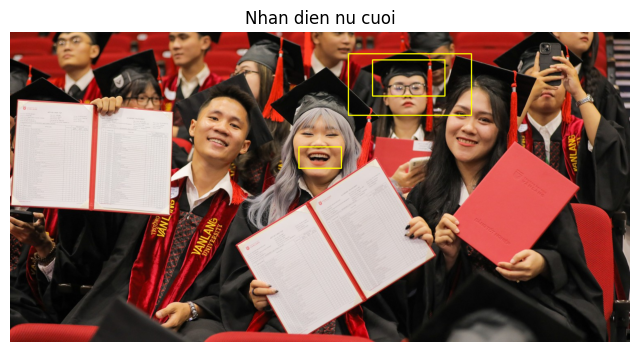

In [10]:
# =========================
# NHẬN DIỆN NỤ CƯỜI
# =========================

smile_cascade = cv.CascadeClassifier('haarcascade_smile.xml')

if smile_cascade.empty():
    raise FileNotFoundError("Không load được file haarcascade_smile.xml")

img_smile = img.copy()
gray_smile = cv.cvtColor(img_smile, cv.COLOR_BGR2GRAY)
rgb_smile = cv.cvtColor(img_smile, cv.COLOR_BGR2RGB)

smiles = smile_cascade.detectMultiScale(
    gray_smile,
    scaleFactor=1.7,
    minNeighbors=20,
    minSize=(25, 25)
)

for (x, y, w, h) in smiles:
    cv.rectangle(rgb_smile, (x, y), (x + w, y + h), (255, 255, 0), 2)

print("Số nụ cười phát hiện được:", len(smiles))

PhuongMai.figure(figsize=(8, 6))
PhuongMai.imshow(rgb_smile)
PhuongMai.title("Nhan dien nu cuoi")
PhuongMai.axis("off")
PhuongMai.show()

Số khuôn mặt phát hiện được: 5


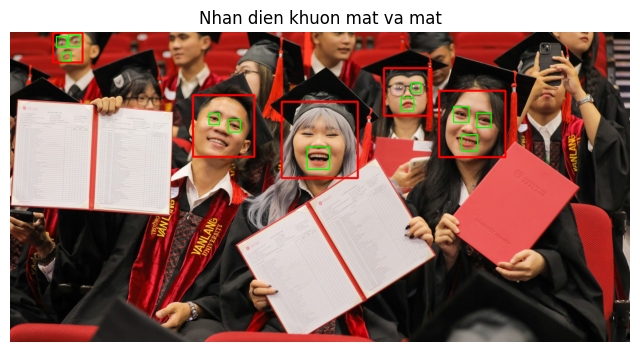

In [12]:
# =========================
# NHẬN DIỆN KHUÔN MẶT + MẮT
# =========================

img_mix = img2.copy()
gray_mix = cv.cvtColor(img_mix, cv.COLOR_BGR2GRAY)
rgb_mix = cv.cvtColor(img_mix, cv.COLOR_BGR2RGB)

faces_mix = face_cascade.detectMultiScale(
    gray_mix,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

for (x, y, w, h) in faces_mix:
    cv.rectangle(rgb_mix, (x, y), (x + w, y + h), (255, 0, 0), 3)

    roi_gray = gray_mix[y:y+h, x:x+w]
    roi_color = rgb_mix[y:y+h, x:x+w]

    eyes_mix = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=6,
        minSize=(15, 15)
    )

    for (ex, ey, ew, eh) in eyes_mix:
        cv.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

print("Số khuôn mặt phát hiện được:", len(faces_mix))

PhuongMai.figure(figsize=(8, 6))
PhuongMai.imshow(rgb_mix)
PhuongMai.title("Nhan dien khuon mat va mat")
PhuongMai.axis("off")
PhuongMai.show()